<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRWfkZ5RWN2bqzfx_cHHUqc6ijjDfqm75LHT7kTLo9Tw5jo1FgbUHazSpY&s=10"width=800></a>
<center><font size=8></center></font>

**<center> <font size=8> AI-driven Sentiment Analysis for Stock Market News </center>**

#INTRODUCTION

This project uses Generative AI and Natural Language Processing (NLP) to analyze financial news headlines and predict stock price movement. News text is converted into numerical embeddings and used to train a machine learning model. The model classifies whether a stock price is likely to move Up or Down based on the given news.

#WORKFLOW

*Data Collection

*Data Cleaning


*Exploratory Data Analysis

*Text Preprocessing

*Word Embeddings

*Model Training

*Model Evaluation

*Final Prediction

<center><p float="center">
  <img src="https://images.openai.com/static-rsc-4/AAN9U-SKmwnsjSQC2zA64XSDGLayZvSjSd6zIRMZkKARR31EReWATtC2iM_qHscnpA4SjOY9pIc3_YQ5CerCjbq_4Va2nJtLzKOOJJ5TpViiCeVMkKisIkaYUiRorZyFhf_JrdAytQiQeK9GgIqJa5fpACFbZZ-uTnzXZV9x4lY7UIXpJVdzY_BQD9Fi-rxl?purpose=fullsize"width=800></a>
<center><font size=8></center></font>

#OBJECTIVE

The main objective of this project is to build a machine learning model that predicts stock price movement using financial news headlines. It involves preprocessing text data, generating embeddings, training a classification model, and evaluating its performance for accurate prediction.

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

The required Python libraries are imported to perform data preprocessing, machine learning, and data visualization. These libraries provide the tools needed to build, train, and evaluate the prediction model.

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GEN AI/stock_news.csv")

In [ ]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

The dataset is loaded and explored to understand its structure, size, and available features. An initial overview helps identify the data format and prepares it for preprocessing and model development.

###**Checking the first 5 rows**

In [ ]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [ ]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [ ]:
data.shape

(349, 8)

###**Checking for missing values**

In [ ]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [ ]:
# checking for duplicate values
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Display the duplicate rows (optional)
duplicate_rows



Number of duplicate rows: 0


,Date,News,Open,High,Low,Close,Volume,Label


In [ ]:
data.duplicated().sum()

0

## **Exploratory Data Analysis**

## Objectives of EDA

• Understand dataset structure
• Identify missing values
• Analyze feature distribution
• Find correlations
• Detect patterns

Exploratory Data Analysis (EDA) is performed to understand the distribution and characteristics of the dataset. It includes examining the target classes, checking for missing values, and visualizing patterns to gain insights before building the prediction model.

In [ ]:
# To display the structure of data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [ ]:
#converting object column 'Date' to datetime
data.Date = pd.to_datetime(data.Date)


In [ ]:
# To ensure the data type of Date
data['Date'].dtype

dtype('<M8[ns]')

In [ ]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

Univariate analysis is performed to examine the distribution of individual variables in the dataset. It helps identify the frequency of target classes, detect missing values, and understand the characteristics of each feature independently.

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

data.hist(figsize=(12,8))
plt.show()


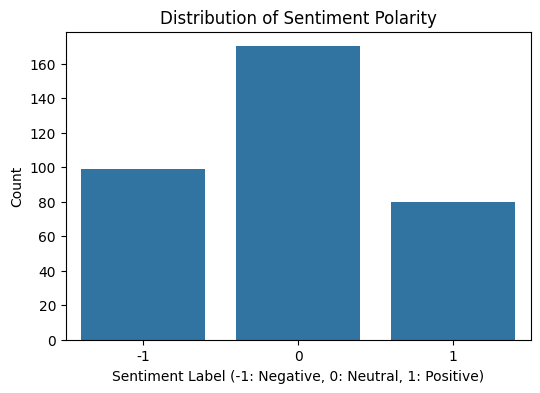

In [ ]:
# Distribution of sentiment polarity
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.show()

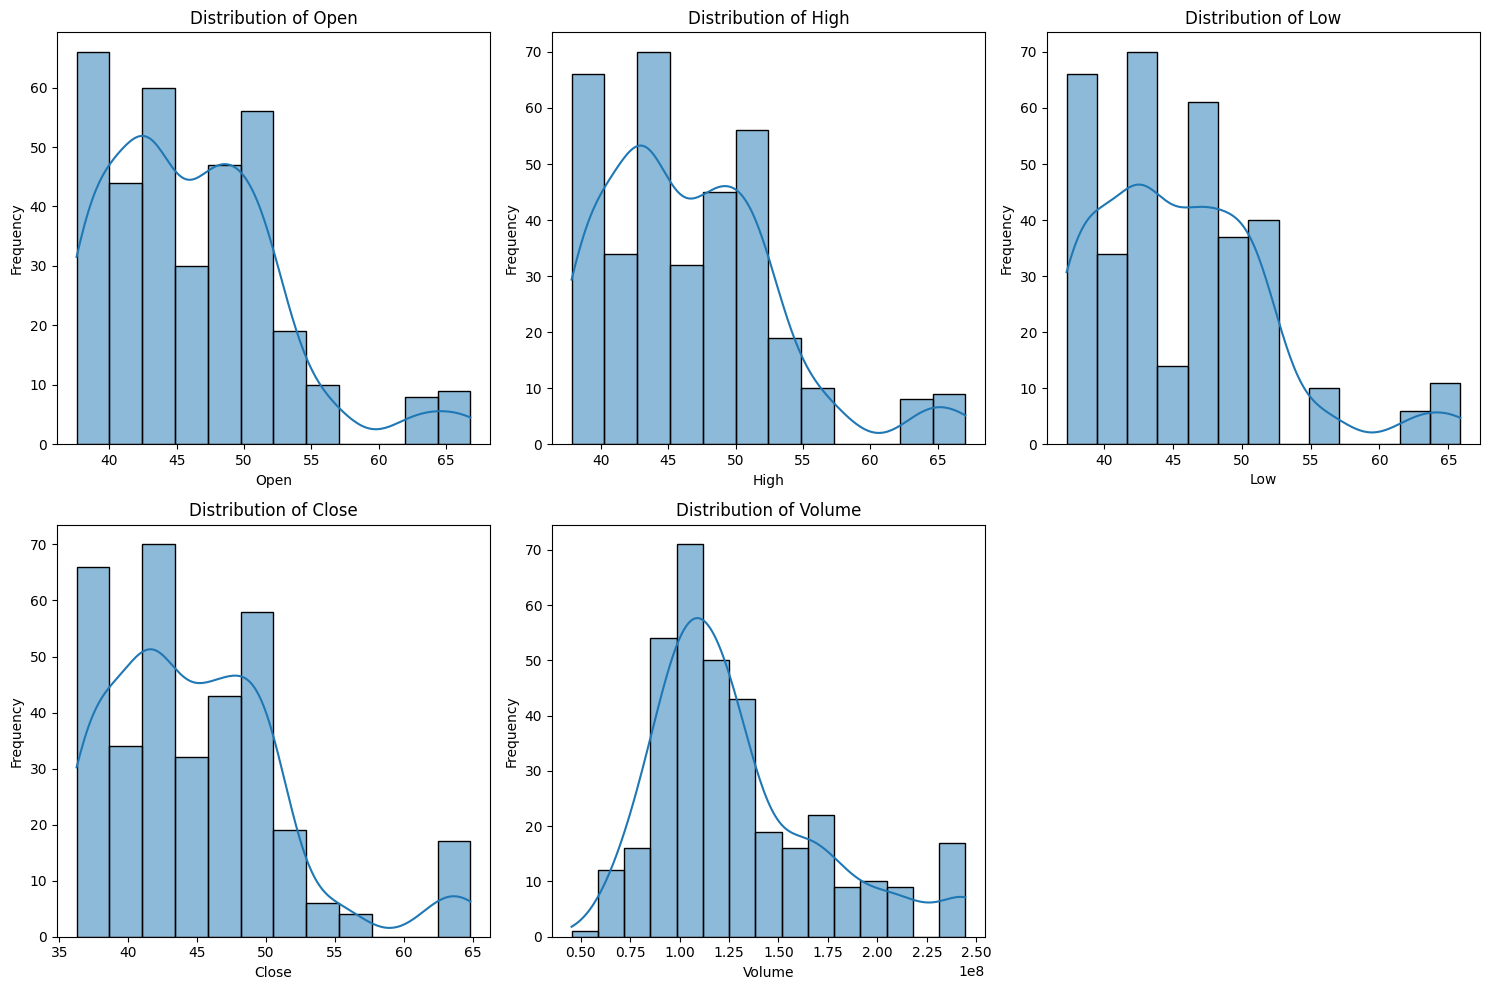

In [ ]:
# Plot Distribution of all Numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

In [ ]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))
# Summary statistics of news length
print(data['News_Length'].describe())



count    349.000000
mean      48.349570
std        5.717324
min       18.000000
25%       45.000000
50%       49.000000
75%       52.000000
max       60.000000
Name: News_Length, dtype: float64


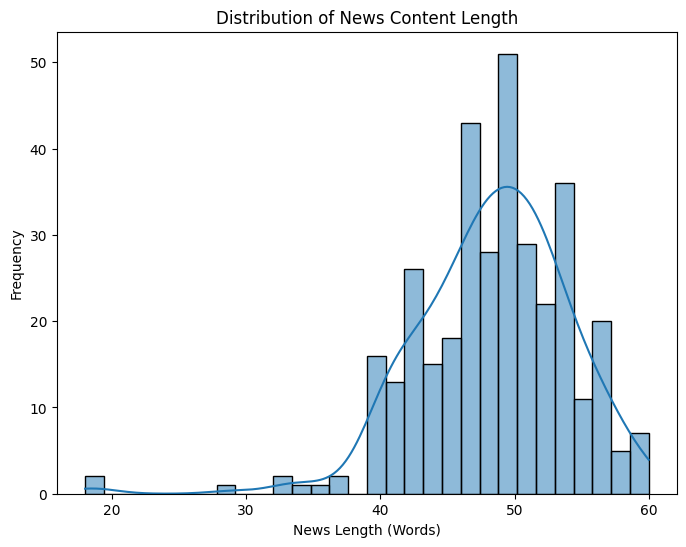

In [ ]:
# Plot distribution
plt.figure(figsize=(8, 6))
sns.histplot(data['News_Length'], kde=True, bins=30)
plt.title('Distribution of News Content Length')
plt.xlabel('News Length (Words)')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

In [ ]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


This cell aggregates the stock price and volume data by month. It first extracts the 'YearMonth' from the 'Date' column and then calculates the average 'High', 'Low', 'Open', 'Close', and 'Volume' for each month. This provides a monthly overview of the stock's performance.

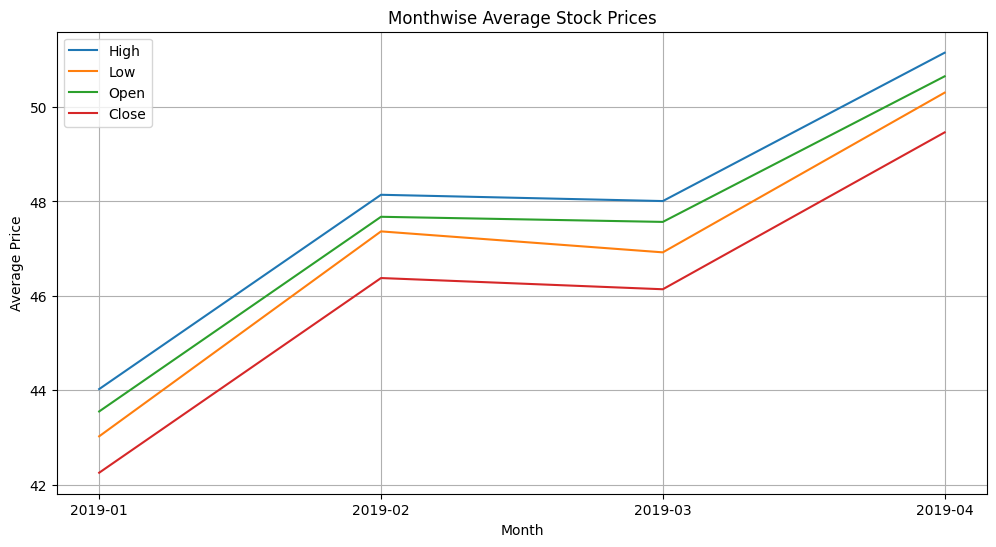

In [ ]:
# plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(12, 6))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['High'], label='High')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Low'], label='Low')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Open'], label='Open')
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Close'], label='Close')
plt.title('Monthwise Average Stock Prices')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.legend()
plt.grid(True)
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

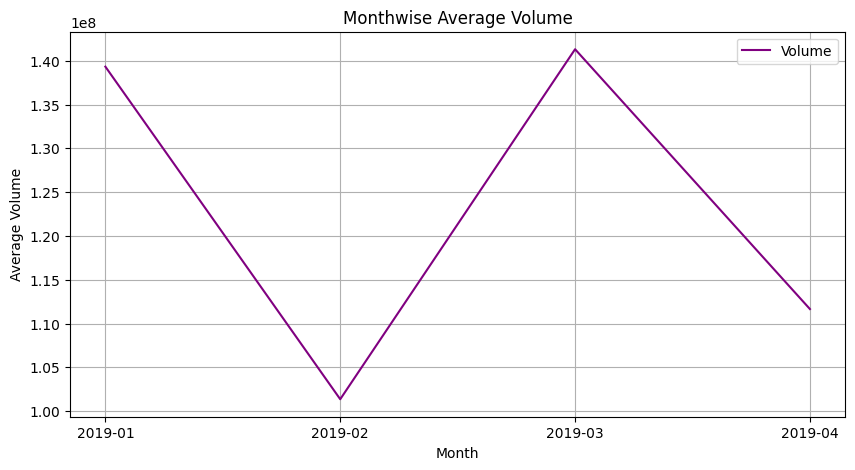

In [ ]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(10, 5))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Volume'], label='Volume', color='purple')
plt.title('Monthwise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.legend()
plt.grid(True)
plt.show()

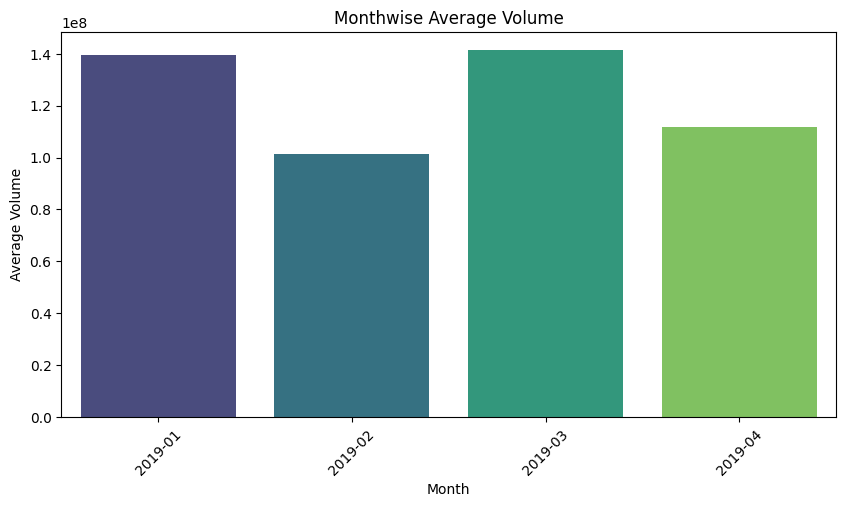

In [ ]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(10, 5))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='viridis')
plt.title('Monthwise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.show()



This bar plot provides an alternative visualization of the month-wise average trading volume. Bar plots can sometimes offer a clearer comparison between categories (months in this case) than line plots, especially when looking at discrete periods.

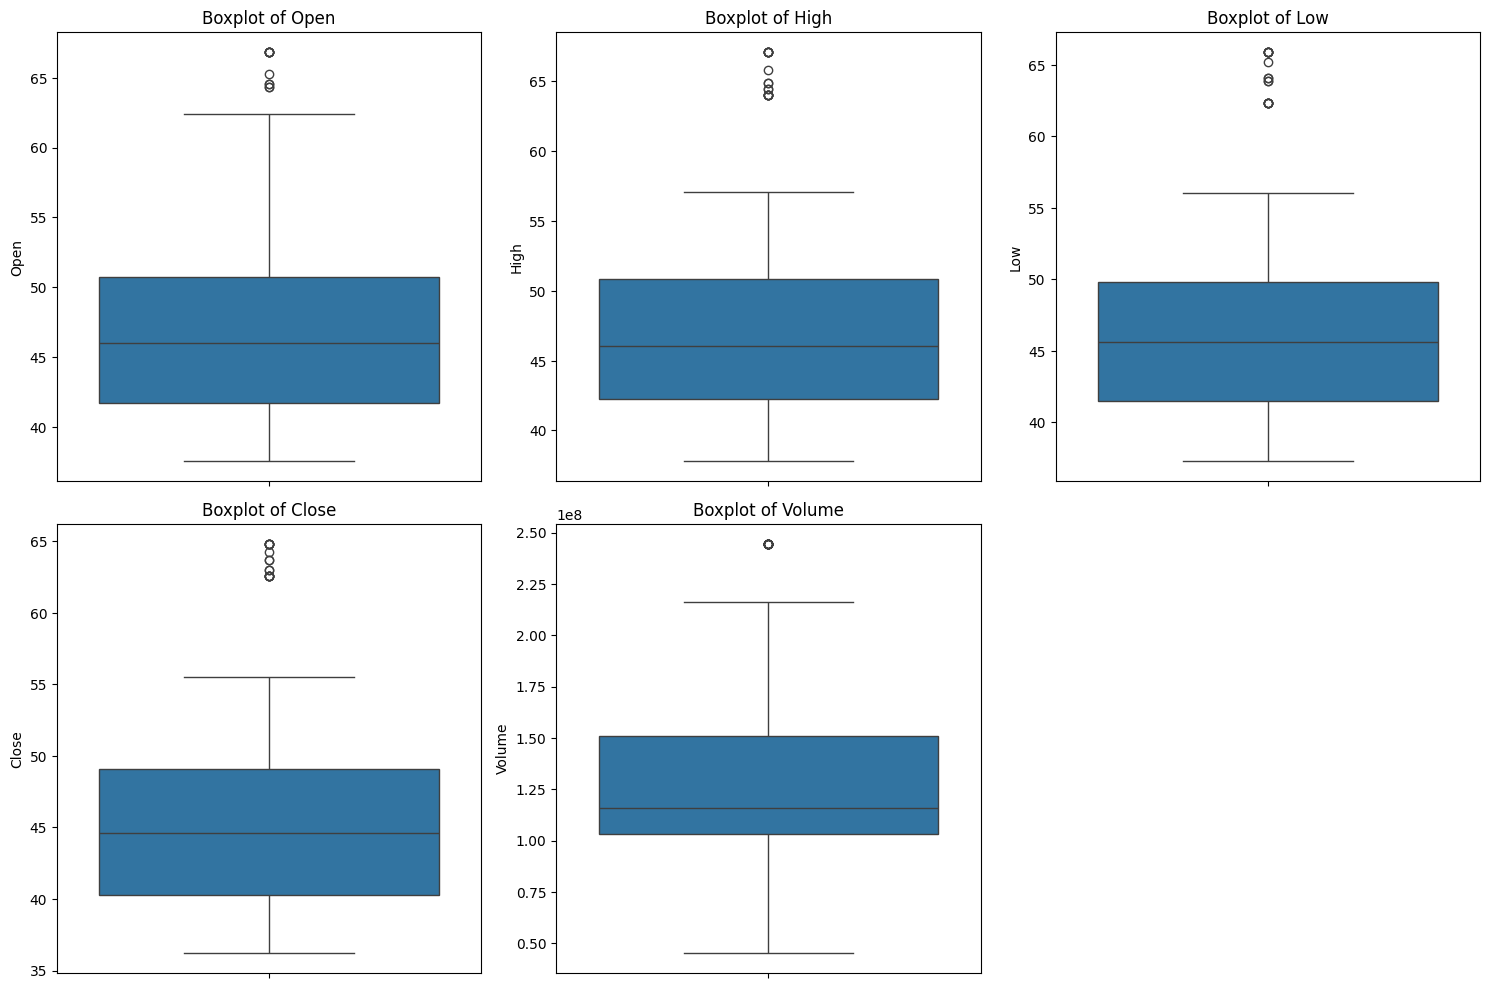

In [ ]:
# Boxplot to identify outliers
numeric_cols_for_boxplot = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols_for_boxplot, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Bivariate Analysis**

Bivariate analysis is performed to examine the relationship between two variables. It helps identify how different features are associated with the target variable and provides insights that are useful for building an accurate prediction model.

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

Correlation analysis is used to measure the strength and direction of the relationship between variables. It helps identify highly related features and provides insights that can improve feature selection and model performance.

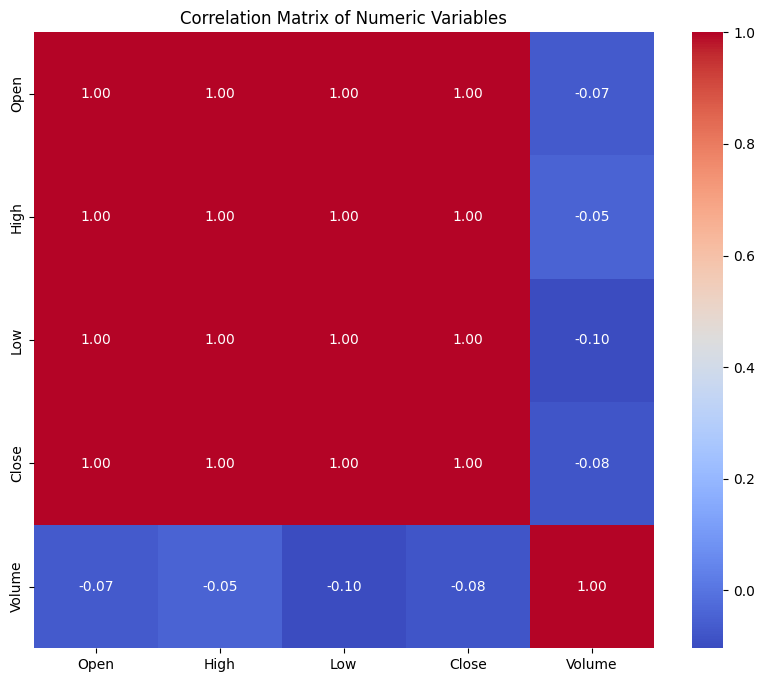

In [ ]:
# Correlation matrix to check if variables move together or have correlations
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

This heatmap visualizes the correlation matrix of the numeric variables ('Open', 'High', 'Low', 'Close', 'Volume'). It helps to identify the strength and direction of linear relationships between these variables. High positive correlation (closer to 1) indicates that variables move in the same direction, while high negative correlation (closer to -1) indicates movement in opposite directions. A value near 0 suggests a weak or no linear relationship.

### **Sentiment Polarity vs Price**

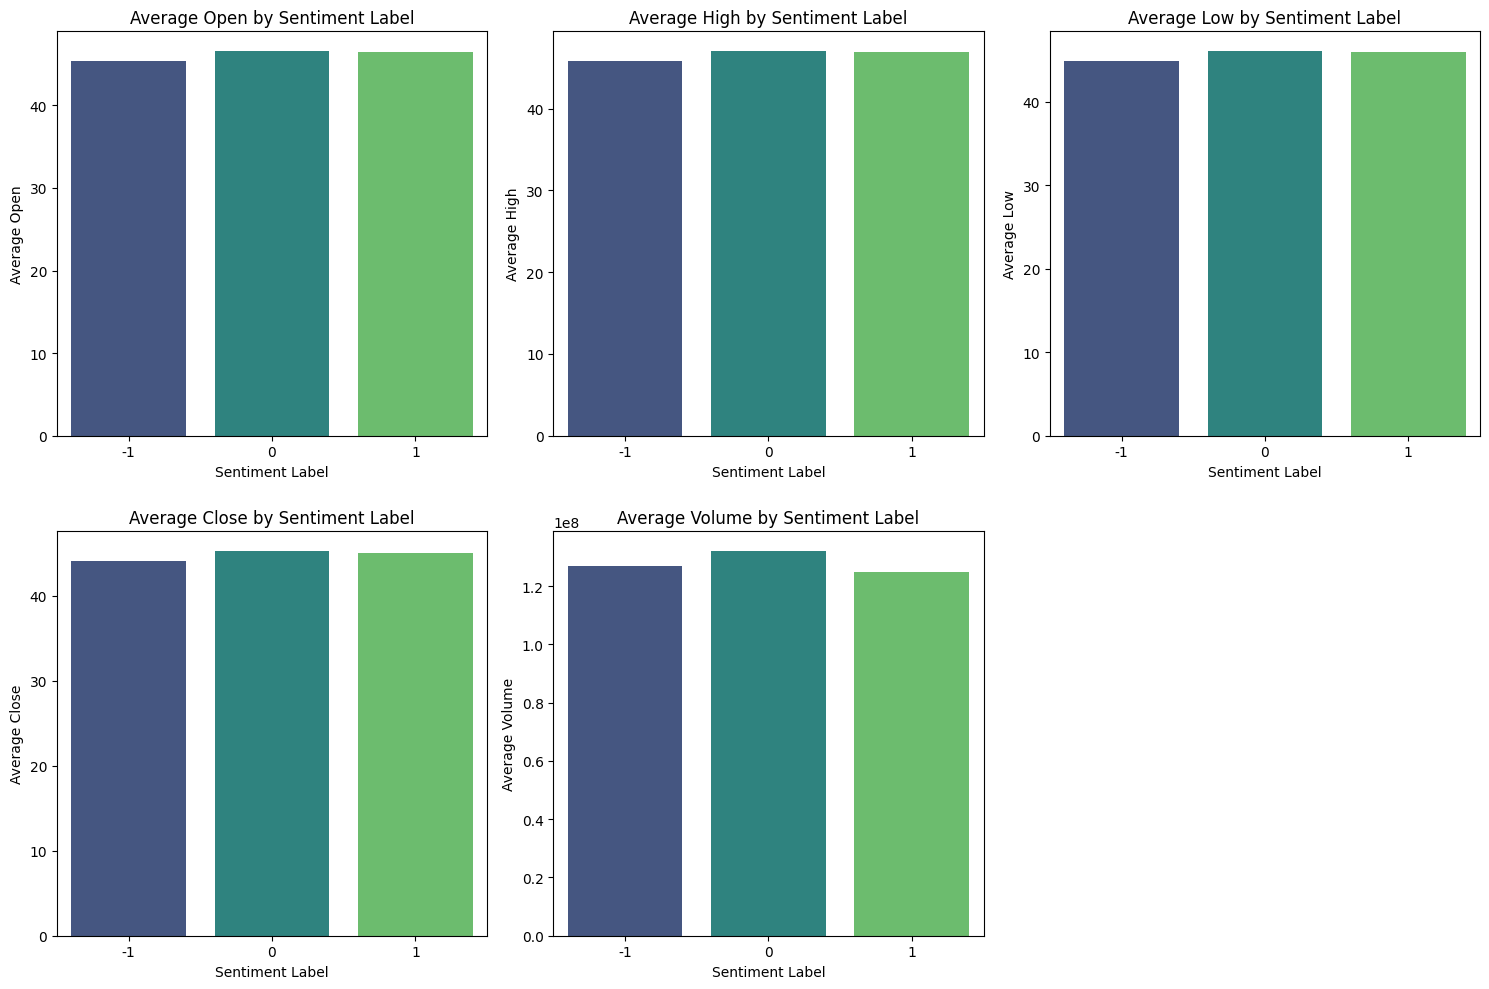

In [ ]:
#Sentiment Polarity with all numeric variables
sentiment_avg = data.groupby('Label')[['Open', 'High', 'Low', 'Close', 'Volume']].mean().reset_index()

plt.figure(figsize=(15, 10))
for i, col in enumerate(['Open', 'High', 'Low', 'Close', 'Volume'], 1):
    plt.subplot(2, 3, i)
    sns.barplot(x='Label', y=col, data=sentiment_avg, palette='viridis')
    plt.title(f'Average {col} by Sentiment Label')
    plt.xlabel('Sentiment Label')
    plt.ylabel(f'Average {col}')
plt.tight_layout()
plt.show()


These bar plots display the average 'Open', 'High', 'Low', 'Close', and 'Volume' grouped by the sentiment 'Label'. This helps to understand how different sentiment polarities (-1: Negative, 0: Neutral, 1: Positive) might correspond to average stock prices and trading volumes, indicating potential relationships between news sentiment and market behavior.

### **Time Series Analysis (Date vs Price)**

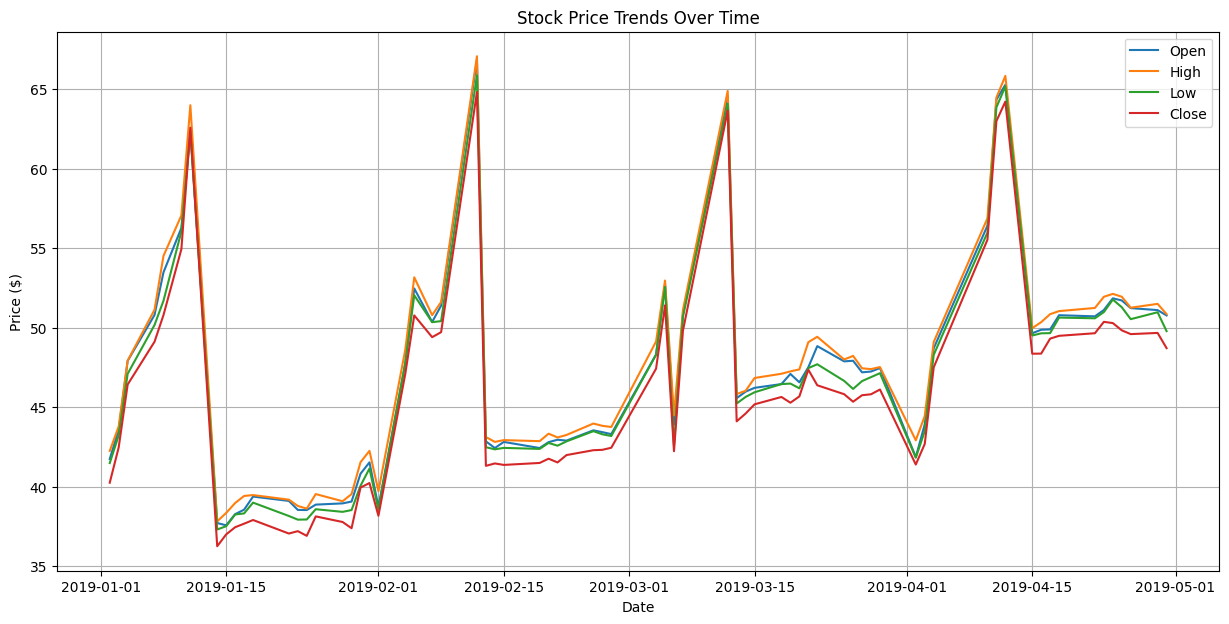

In [ ]:
#Time Series Analysis (Date vs Price columns)
plt.figure(figsize=(15, 7))
plt.plot(data['Date'], data['Open'], label='Open')
plt.plot(data['Date'], data['High'], label='High')
plt.plot(data['Date'], data['Low'], label='Low')
plt.plot(data['Date'], data['Close'], label='Close')
plt.title('Stock Price Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

This time series plot illustrates the trends of 'Open', 'High', 'Low', and 'Close' stock prices over time. It allows for the visual identification of patterns, seasonality, and significant events that might have influenced stock prices during the observed period.

### **Distribution of News Length Across Sentiment Categories**

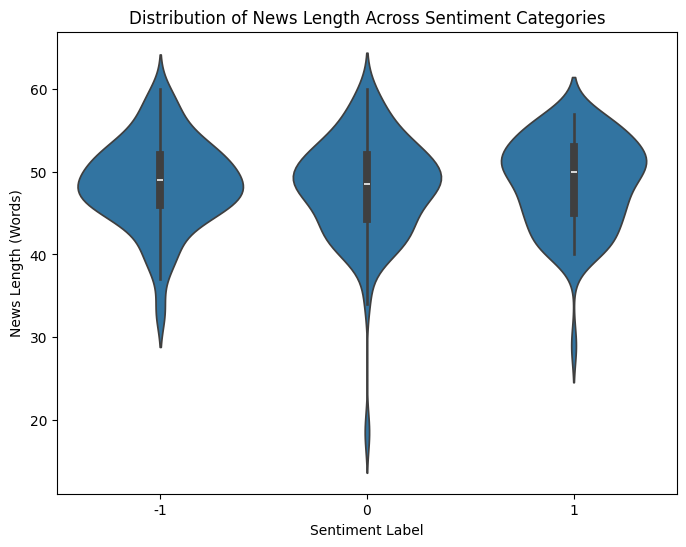

In [ ]:
# Distribution of News Length Across Sentiment Categories
plt.figure(figsize=(8, 6))
sns.violinplot(x='Label', y='News_Length', data=data)
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label')
plt.ylabel('News Length (Words)')
plt.show()

This violin plot shows the distribution of news article lengths across different sentiment categories (-1, 0, 1). It combines aspects of a box plot and a kernel density plot, providing insights into the spread and density of news lengths for each sentiment, and whether certain sentiment types are associated with longer or shorter articles.

## **Data Preprocessing**

Data preprocessing is performed to clean and prepare the dataset for model training. It includes handling missing values, converting text into embeddings, and transforming the data into a suitable format for machine learning algorithms.

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

This markdown cell describes the strategy for splitting the dataset. A common practice in machine learning is to divide the data into a training set (used to train the model) and a test set (used to evaluate the model's performance on unseen data). An 80:20 ratio is used here, meaning 80% of the data will be used for training and 20% for testing. random_state=42 ensures that the split is reproducible, yielding the same training and testing sets every time the code is run.





In [ ]:
# Storing target variable
y = data['Label']

Here, the 'Label' column is extracted from the DataFrame and assigned to the variable y. This 'Label' column represents the sentiment polarity (the target variable) that the models will be trained to predict. Isolating the target variable is a fundamental step in supervised learning tasks.




  Word2Vec        | Sentence Transformer |
| --------------- | -------------------- |
| Word Level      | Sentence Level       |
| Context Limited | Context Aware        |
| Older Method    | Modern Method        |
| Fast            | More Accurate        |


<center><p float="center">
  <img src="https://images.openai.com/static-rsc-4/9o_ffRyscHR46hAWcq3v-YldJlY0uGXYWrgkki1Qxr_iCmqIlSXVRN9q_bFxICNcW2rmLKRDrZaj6K6cEXy3cH1sxbrxeH7HXTBOBFengx-iyEOXNz5p3a2k00B7Q1hD_fPVZW0XFbLKmGG-yhsaPCEjjlzXIOel3CrhFaXlUQzrIEmT7CDk-PkDnvy4tm9Y?purpose=fullsize"width=600></a>
<center><font size=6></center></font>

## **Word Embeddings**


#### **Word2Vec**

In [ ]:
# Creating a list of all words in our data
# Creating a list of all words in our data
tokenized_news = data['News'].apply(lambda x: x.split())
print(tokenized_news.head())

0        [The, tech, sector, experienced, a, significant, decline, in, the, aftermarket, following, Apple's, Q1, revenue, warning., Notable, suppliers,, including, Skyworks,, Broadcom,, Lumentum,, Qorvo,, and, TSMC,, saw, their, stocks, drop, in, response, to, Apple's, downward, revision, of, its, revenue, expectations, for, the, quarter,, previously, announced, in, January.]
1    [Apple, lowered, its, fiscal, Q1, revenue, guidance, to, $84, billion, from, earlier, estimates, of, $89-$93, billion, due, to, weaker, than, expected, iPhone, sales., The, announcement, caused, a, significant, drop, in, Apple's, stock, price, and, negatively, impacted, related, suppliers,, leading, to, broader, market, declines, for, tech, indices, such, as, Nasdaq, 10]
2                                 [Apple, cut, its, fiscal, first, quarter, revenue, forecast, from, $89-$93, billion, to, $84, billion, due, to, weaker, demand, in, China, and, fewer, iPhone, upgrades., CEO, Tim, Cook, also, mentioned, const

This cell tokenizes each news article, converting the raw text into a list of individual words. This is a crucial preprocessing step for many NLP tasks, especially for training word embedding models like Word2Vec, as it breaks down sentences into their fundamental units for analysis.

In [ ]:
# Initializing and training the Word2Vec model
# vector_size (embedding_dim) is set to 100 as a common practice, window is 5 for context window,
# min_count=1 ensures all words are included, sg=0 for CBOW model
vec_size = 100
model_Word2Vec = Word2Vec(sentences=tokenized_news, vector_size=vec_size, window=5, min_count=1, sg=0)

# Summarize the loaded model
print(model_Word2Vec)

Word2Vec<vocab=4681, vector_size=100, alpha=0.025>


Here, a Word2Vec model is initialized and trained on the tokenized news data. The key parameters are:

vector_size=100: Defines the dimensionality of the word embeddings (each word will be represented by a 100-dimensional vector).
window=5: Specifies the maximum distance between the current and predicted word within a sentence.
min_count=1: Ignores all words with a total frequency lower than this. Setting it to 1 ensures all words are included.
sg=0: Uses the Continuous Bag-of-Words (CBOW) architecture, which predicts the current word based on its context.

In [ ]:
# Checking the number of words in the vocabulary
print(f"Number of words in vocabulary: {len(model_Word2Vec.wv)}")

# Checking the size of the word vectors
print(f"Size of word vectors: {model_Word2Vec.wv.vector_size}")

Number of words in vocabulary: 4681
Size of word vectors: 100


These print statements confirm the size of the vocabulary learned by the Word2Vec model and the dimensionality of the generated word vectors. This helps verify that the model has been trained as expected and that the embeddings have the specified vector_size.

In [ ]:
# Retrieving word vectors for all the words present in the model's vocabulary
words = model_Word2Vec.wv.index_to_key

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = model_Word2Vec.wv

print(f"First 5 words in vocabulary: {words[:5]}")
print(f"Vector for '{words[0]}': {word_vector_dict[words[0]][:5]}...")



First 5 words in vocabulary: ['and', 'the', 'to', 'a', 'in']
Vector for 'and': [-0.20047738  0.22961509  0.04671377  0.05407253  0.03570019]...


This cell retrieves the words from the model's vocabulary and stores their vector representations in a dictionary. It then displays the first few words and an example of a word's vector, demonstrating how each word is represented numerically.

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

This helper function, average_vectorizer_Word2Vec, takes a document (news article) as input and converts it into a single fixed-size vector. It does this by averaging the Word2Vec embeddings of all the words present in the document. This approach allows us to represent an entire document as a single numerical vector, which can then be used as input for machine learning models.

In [ ]:
# creating a dataframe of the vectorized documents
# creating a dataframe of the vectorized documents
X = pd.DataFrame([average_vectorizer_Word2Vec(doc) for doc in data['News']], index=data.index)

# Display the first 5 rows of X
print("First 5 rows of X (Word2Vec embeddings):")
print(X.head())

# Display the shape of X
print("\nShape of X:")
print(X.shape)


First 5 rows of X (Word2Vec embeddings):
         0         1         2         3         4         5         6   \
0 -0.071209  0.080002  0.014343  0.015910  0.014999 -0.105701  0.021805   
1 -0.066242  0.077803  0.014434  0.015237  0.015248 -0.100995  0.019216   
2 -0.061662  0.072968  0.013356  0.014453  0.015036 -0.092781  0.018418   
3 -0.072421  0.082245  0.014034  0.016610  0.014970 -0.106266  0.021756   
4 -0.069332  0.079413  0.013009  0.016054  0.016189 -0.100109  0.020493   

         7         8         9   ...        90        91        92        93  \
0  0.156434 -0.069497 -0.052121  ...  0.086013 -0.003204  0.018828  0.005342   
1  0.150592 -0.068704 -0.049764  ...  0.082828 -0.003648  0.017470  0.003824   
2  0.139836 -0.062169 -0.045931  ...  0.076253 -0.003404  0.016421  0.003165   
3  0.157272 -0.070411 -0.051978  ...  0.087055 -0.002271  0.018303  0.002486   
4  0.152455 -0.068106 -0.049332  ...  0.083614 -0.004250  0.017601  0.003369   

         94        95      

This code applies the average_vectorizer_Word2Vec function to each news article in the dataset, transforming all news text into numerical feature vectors. The resulting X DataFrame contains these Word2Vec embeddings for each document, ready for use as input features for a machine learning model. The shape of X confirms the number of documents and the dimensionality of the embeddings.

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [ ]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

##### Encoding the dataset

In [ ]:
embedding_matrix = model.encode(data['News'], show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
# printing the shape of the embedding matrix
print(f"Shape of embedding matrix: {embedding_matrix.shape}")


Shape of embedding matrix: (349, 768)


This code block encodes all the news articles using the loaded SentenceTransformer model. The model.encode() method converts each news article into a high-dimensional vector, forming the embedding_matrix. The shape of this matrix (e.g., 349, 768) indicates that there are 349 news articles, and each article is represented by a 768-dimensional vector, effectively capturing its semantic content.

## **Sentiment Analysis**

This section focuses on building and evaluating sentiment analysis models using different text embedding techniques (Word2Vec and Sentence Transformers) combined with traditional machine learning (Random Forest) and deep learning (Neural Network) approaches

### **Model Evaluation Criterion**

This section outlines the key metrics and visualization tools used to assess the performance of the classification models. A confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class, while classification metrics (accuracy, recall, precision, and F1-score) offer a quantitative summary of the model's effectiveness.


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

This plot_confusion_matrix function visualizes the performance of a classification model. It generates a heatmap representation of the confusion matrix, which clearly shows the number of true positive, true negative, false positive, and false negative predictions for each class. This visual aid is invaluable for understanding where a model succeeds and where it makes errors.

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

The model_performance_classification_sklearn function calculates several standard classification metrics: accuracy, recall, precision, and F1-score. These metrics provide a comprehensive quantitative evaluation of a model's predictive capabilities, especially important in multi-class classification problems like sentiment analysis.

## **Build Random Forest Models using different text embeddings**

This section details the construction of various Random Forest models, each leveraging a different text embedding technique. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. This approach helps to prevent overfitting and improve generalization.

## Why Random Forest?

1 Handles high dimensional data

2 Reduces overfitting

3 High accuracy

4 Easy interpretation

<center><p float="center">
  <img src="https://images.openai.com/static-rsc-4/liHv3tx6xYIQWOxiIQ4X8eJ0Fgmt8q0RDXPBQCm5bVsi0b1rWZ5u5qeA3nfui6ElT90oRaeFFNPpA4vv_e3nUBViCM3521t-4A4qfshJnVf63y429jYhO5BsdwG7ivB0S5sWOxxV32UJaZ8cB0AZVqBrvUHFiNJycbnnzziv11mHqFAQ_fkv5dBDHTEo35rk?purpose=fullsize"width=600></a>
<center><font size=8></center></font>

### **Word2Vec-Random Forest Model**

In [ ]:
# Storing independent variable

X_word2vec = X


Here, the X_word2vec (which contains the Word2Vec embeddings previously generated) is assigned as the independent variable for this model. This ensures that the Random Forest model will be trained on the numerical representations derived from the Word2Vec algorithm, allowing it to interpret the semantic information captured by those embeddings.

In [ ]:
# To fix the previous error related to incorrect X_train/X_test for Word2Vec NN:
# The previous X was from Sentence Transformer BAAI.
# Now, explicitly setting X to X_word2vec before splitting.
X = X_word2vec

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Before training the model, the dataset is split into training and testing sets. X (Word2Vec embeddings) and y (sentiment labels) are divided using an 80:20 ratio. random_state=42 ensures reproducibility of the split, meaning the same data points will be in the training and testing sets each time this code is executed. This separation is crucial for evaluating the model's performance on unseen data.





In [ ]:
# Building the model
# Building the model
rf_model_word2vec = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_word2vec.fit(X_train, y_train)

# Fitting on train data


RandomForestClassifier(random_state=42)

A RandomForestClassifier model is initialized with random_state=42 for reproducibility. The model is then trained using the fit method on the X_train (Word2Vec embeddings of training news articles) and y_train (corresponding sentiment labels). This step allows the Random Forest to learn the patterns and relationships between the word embeddings and the sentiment polarities from the training data.

In [ ]:
# Predicting on train data
# Predicting on train data
y_pred_train = rf_model_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_model_word2vec.predict(X_test)


# Predicting on test data


Once the Random Forest model is trained, it's used to make predictions on both the training data (X_train) and the unseen test data (X_test). The predict method outputs the predicted sentiment labels for each news article in the respective datasets. These predictions (y_pred_train, y_pred_test) will then be used to evaluate the model's performance.

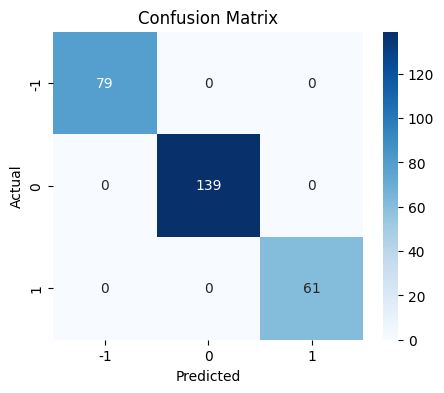

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

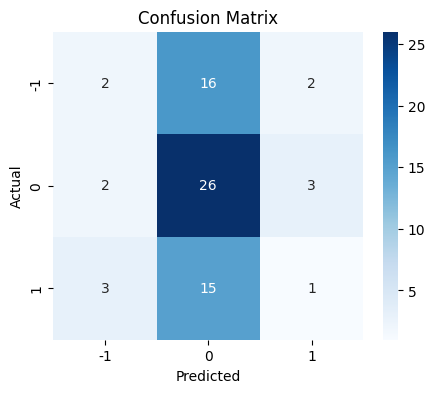

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

This code block calls the previously defined plot_confusion_matrix function to visualize the performance of the Word2Vec Random Forest model on the training data. A confusion matrix provides a detailed breakdown of correct and incorrect classifications, showing how many instances of each actual sentiment class were predicted as each sentiment class.

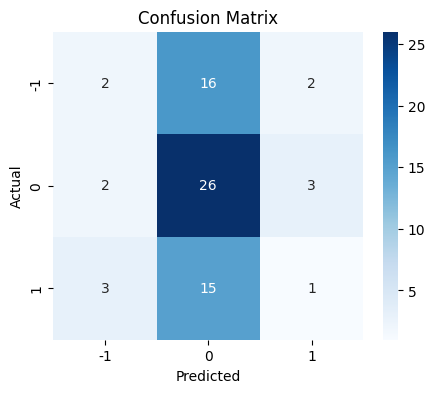

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

This code block calls the plot_confusion_matrix function to visualize the performance of the Word2Vec Random Forest model on the test data. This is a critical step, as it indicates how well the model generalizes to new, unseen news articles. A good model should perform similarly on both training and test data, without significant overfitting.

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.414286 0.414286   0.328876 0.325731


Here, the model_performance_classification_sklearn function is used to calculate key classification metrics (Accuracy, Recall, Precision, F1-score) for the Word2Vec Random Forest model on both the training and test datasets. These metrics provide a quantitative assessment of the model's performance, helping to understand its strengths and weaknesses in classifying sentiment.

###**Sentence Transformer-Random Forest Model**

This section outlines the process of building a Random Forest model using embeddings generated by the SentenceTransformer with the BAAI/bge-base-en-v1.5 model. This approach leverages the contextual understanding of Sentence Transformers to represent news articles as dense vectors, which are then fed into the Random Forest classifier for sentiment prediction. The expectation is that these richer embeddings might lead to improved performance compared to Word2Vec.

In [ ]:
# Storing independent variable
X = embedding_matrix


The embedding_matrix (containing the SentenceTransformer BAAI embeddings) is assigned as the independent variable X for this model. This ensures that the Random Forest model will be trained on the sophisticated, context-aware vector representations of the news articles, aiming to capture deeper semantic relationships for sentiment analysis.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Similar to the previous model, the data is split into training and testing sets (X being the SentenceTransformer BAAI embeddings and y being the sentiment labels) using an 80:20 ratio with random_state=42 for reproducibility. This split is essential for an unbiased evaluation of the model's ability to generalize to new, unseen sentiment data.

In [ ]:
# Building the model
rf_model_transformer_BAAI = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_transformer_BAAI.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

A RandomForestClassifier is initialized with random_state=42 and trained (fit method) using the X_train (SentenceTransformer BAAI embeddings) and y_train (corresponding sentiment labels). This step trains the ensemble model to learn patterns from the contextual embeddings, enabling it to classify the sentiment of news articles.

In [ ]:
# Predicting on train data
y_pred_train_transformer_BAAI = rf_model_transformer_BAAI.predict(X_train)

# Predicting on test data
y_pred_test_transformer_BAAI = rf_model_transformer_BAAI.predict(X_test)


Predictions are generated for both the training and test sets using the trained SentenceTransformer BAAI Random Forest model. These y_pred_train_transformer_BAAI and y_pred_test_transformer_BAAI predictions represent the model's classification of sentiment based on the input embeddings, and they will be used for subsequent evaluation.

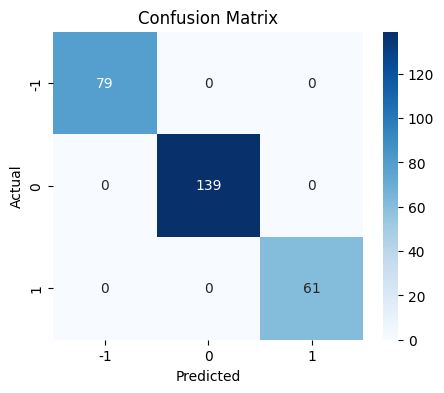

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

This code block visualizes the performance of the SentenceTransformer BAAI Random Forest model on the training data using a confusion matrix. It helps to understand how accurately the model classified the sentiment of the news articles it was trained on.

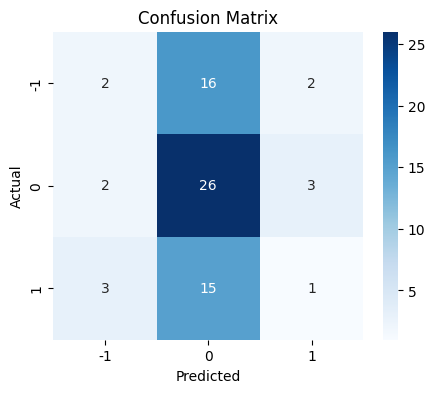

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

This code block visualizes the performance of the SentenceTransformer BAAI Random Forest model on the test data using a confusion matrix. This visualization is crucial for assessing the model's generalization capabilities to new, unseen data.

In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.414286 0.414286   0.328876 0.325731


The model_performance_classification_sklearn function is utilized here to compute and display the accuracy, recall, precision, and F1-score for the SentenceTransformer BAAI Random Forest model on both the training and test sets. These metrics provide a quantitative evaluation of the model's effectiveness in sentiment classification, allowing for comparison with other models.

### **Building Neural Network Models using different text embeddings**

This section delves into building Neural Network models for sentiment analysis, leveraging both Word2Vec and Sentence Transformer embeddings. Neural Networks are powerful deep learning models capable of learning complex patterns and representations from data. By feeding them text embeddings, we aim to capture intricate relationships within the news articles to predict sentiment more effectively.

### **Word2Vec-Neural Network Model**

This subsection focuses on building a Neural Network model that uses Word2Vec embeddings as its input features. This combination aims to see if the deep learning architecture can better utilize the semantic information encoded by Word2Vec compared to a traditional machine learning model like Random Forest.

In [ ]:
# Storing independent variable
X = X_word2vec

The X_word2vec (containing the Word2Vec embeddings) is explicitly set as the independent variable X for the Neural Network model. This ensures that the Neural Network will process these 100-dimensional vectors, each representing a news article, to learn sentiment patterns.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

The dataset is split into training and testing sets (80:20 ratio, random_state=42) using the X (Word2Vec embeddings) and y (sentiment labels). This is a standard practice to evaluate the Neural Network's ability to generalize to unseen data, preventing an overly optimistic assessment of its performance.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

The sentiment labels in y_train and y_test (which are -1, 0, 1) are mapped to 0, 1, 2, respectively. This remapping is necessary because sparse_categorical_crossentropy loss function in Keras/TensorFlow expects integer labels starting from 0 for multi-class classification. This ensures compatibility with the neural network's output layer, which uses a 'softmax' activation for probability distribution over classes.

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines and compiles the Neural Network model. It's a sequential model with: - Two Dense (fully connected) layers with 'relu' activation and Dropout layers for regularization (to prevent overfitting). - An output Dense layer with 3 neurons (for the three sentiment classes: -1, 0, 1) and 'softmax' activation, which outputs probabilities for each class. The model is compiled with the 'adam' optimizer and 'sparse_categorical_crossentropy' loss function, suitable for multi-class classification with integer labels.

In [ ]:
history = model.fit(
    X_train,
    y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4050 - loss: 1.0928 - val_accuracy: 0.4429 - val_loss: 1.0836
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0644 - val_accuracy: 0.4429 - val_loss: 1.0760
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0500 - val_accuracy: 0.4429 - val_loss: 1.0790
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0449 - val_accuracy: 0.4429 - val_loss: 1.0857
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0463 - val_accuracy: 0.4429 - val_loss: 1.0873
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0379 - val_accuracy: 0.4429 - val_loss: 1.0867
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0416 - val_accuracy: 0.4429 - val_loss: 1.0831
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0381 - val_accuracy: 0.4429 - val_loss: 1.0838


The Neural Network model is trained using the fit method on the X_train (Word2Vec embeddings) and y_train_mapped (mapped sentiment labels). Validation data (X_test, y_test_mapped) is provided to monitor the model's performance on unseen data during training over 20 epochs with a batch size of 32. This process allows the model to learn and adjust its internal weights to minimize the loss and improve accuracy.

In [ ]:
# Predict class probabilities on training data
y_train_preds_Word2Vec_NN = np.argmax(model.predict(X_train), axis=1)

# Convert probabilities to class labels

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
# Predict class probabilities on test data
y_test_preds_Word2Vec_NN = np.argmax(model.predict(X_test), axis=1)

# Convert probabilities to class labels


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


the trained Neural Network model predicts class probabilities for the unseen test data (X_test). Similar to the training predictions, np.argmax converts these probabilities into discrete class labels (0, 1, or 2), forming y_test_preds_Word2Vec_NN. These predictions are crucial for assessing the model's generalization ability to new data.

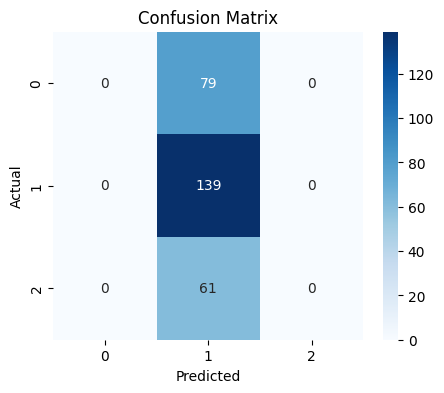

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds_Word2Vec_NN)

This code block utilizes the plot_confusion_matrix function to visualize the performance of the Word2Vec Neural Network model on the training data. It provides a clear picture of how well the model classified sentiments for the data it was trained on.

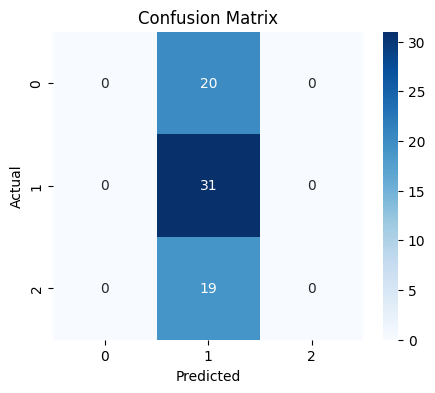

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds_Word2Vec_NN)

This code block visualizes the performance of the Word2Vec Neural Network model on the test data using a confusion matrix. This is essential to understand the model's real-world applicability and its ability to generalize to new, unseen sentiment data.

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds_Word2Vec_NN)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds_Word2Vec_NN)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


The model_performance_classification_sklearn function is called to compute the accuracy, recall, precision, and F1-score for the Word2Vec Neural Network model on both the mapped training and test datasets. These quantitative metrics allow for a comprehensive evaluation of the model's performance and facilitate comparison with other models.

### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

This subsection outlines the process of building a Neural Network model using embeddings generated by the SentenceTransformer with the all-MiniLM-L6-v2 model. This model is generally known for its efficiency and good performance in generating sentence embeddings. The aim here is to combine the expressive power of these contextual embeddings with the learning capabilities of a Neural Network for sentiment analysis.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset is split into training and testing sets (80:20 ratio, random_state=42) using X (which should now contain the SentenceTransformer all-MiniLM-L6-v2 embeddings, as set in a previous cell) and y (sentiment labels). This ensures a robust evaluation of the Neural Network's generalization performance on unseen sentiment data.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

The sentiment labels in y_train and y_test (which are -1, 0, 1) are remapped to 0, 1, 2, respectively. This transformation is necessary for compatibility with the sparse_categorical_crossentropy loss function used in TensorFlow/Keras Neural Networks, which requires integer-encoded target labels starting from zero.

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines and compiles the Neural Network model. It employs a Sequential architecture with two Dense hidden layers (using 'relu' activation) and Dropout layers for regularization, preventing overfitting. The output layer has 3 neurons with 'softmax' activation to predict probabilities for the three sentiment classes. The model is compiled with the 'adam' optimizer and 'sparse_categorical_crossentropy' loss, appropriate for multi-class classification.

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4409 - loss: 1.0826 - val_accuracy: 0.4429 - val_loss: 1.0805
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0568 - val_accuracy: 0.4429 - val_loss: 1.0760
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4982 - loss: 1.0500 - val_accuracy: 0.4429 - val_loss: 1.0804
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4982 - loss: 1.0482 - val_accuracy: 0.4429 - val_loss: 1.0856
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4982 - loss: 1.0474 - val_accuracy: 0.4429 - val_loss: 1.0860
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0386 - val_accuracy: 0.4429 - val_loss: 1.0845
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0410 - val_accuracy: 0.4429 - val_loss: 1.0831
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0442 - val_accuracy: 0.4429 - val_loss: 1.0829


The Neural Network model is trained using the fit method on the X_train (SentenceTransformer all-MiniLM-L6-v2 embeddings) and y_train_mapped (mapped sentiment labels). The validation_data is used to monitor performance on the test set during training. The model is trained for 20 epochs with a batch size of 32, allowing it to learn the complex relationship between the sentence embeddings and sentiment.

In [ ]:
# Predict class probabilities on training data
y_train_preds = np.argmax(model.predict(X_train), axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


After training, the Neural Network model generates class probabilities for the training data (X_train). np.argmax is then applied to these probabilities to derive the predicted sentiment class labels (0, 1, or 2), which are stored in y_train_preds. These predictions are used to evaluate the model's performance on the data it has learned from.

In [ ]:
# Predict class probabilities on test data
y_test_preds = np.argmax(model.predict(X_test), axis=1)



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


The trained Neural Network model predicts class probabilities for the unseen test data (X_test). np.argmax is used to convert these probabilities into discrete class labels (0, 1, or 2), resulting in y_test_preds. These predictions are vital for assessing the model's ability to generalize to new, real-world sentiment analysis tasks.

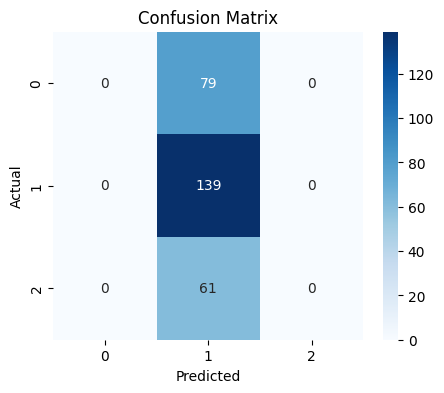

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

This code block visualizes the performance of the SentenceTransformer all-MiniLM-L6-v2 Neural Network model on the training data using a confusion matrix. This helps to confirm that the model has effectively learned the patterns in the training data.

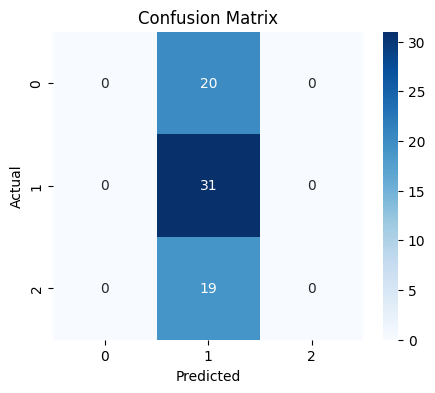

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

This code block visualizes the performance of the SentenceTransformer all-MiniLM-L6-v2 Neural Network model on the test data using a confusion matrix. This visualization is crucial for understanding the model's actual performance on unseen data and identifying any potential issues with generalization.



In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


The model_performance_classification_sklearn function is employed here to calculate and display the accuracy, recall, precision, and F1-score for the SentenceTransformer all-MiniLM-L6-v2 Neural Network model on both the mapped training and test datasets. These metrics provide a comprehensive quantitative assessment, enabling a detailed comparison with other sentiment analysis models developed in this notebook.

###  **Generating Embeddings with Sentence Tranformers using the all-MiniLM-L6-v2 embedding**

In [ ]:
# Initializing the Sentence Transformer model
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# Encoding the dataset
embedding_matrix_minilm = model_minilm.encode(data['News'], show_progress_bar=True)

# printing the shape of the embedding matrix
print(f"Shape of embedding matrix: {embedding_matrix_minilm.shape}")

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Shape of embedding matrix: (349, 384)


### **Sentence Transformer-all-MiniLM-L6-v2 (Random Forest Model)**

In [ ]:

# Storing independent variable
X = embedding_matrix_minilm

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Building the model
rf_model_transformer_MiniLM = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_transformer_MiniLM.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predicting on train data
y_pred_train_transformer_MiniLM = rf_model_transformer_MiniLM.predict(X_train)

# Predicting on test data
y_pred_test_transformer_MiniLM = rf_model_transformer_MiniLM.predict(X_test)

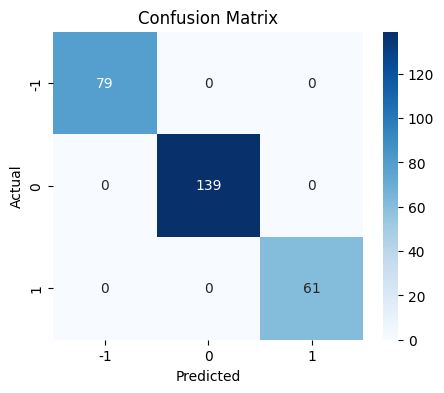

In [ ]:
plot_confusion_matrix(y_train, y_pred_train_transformer_MiniLM)

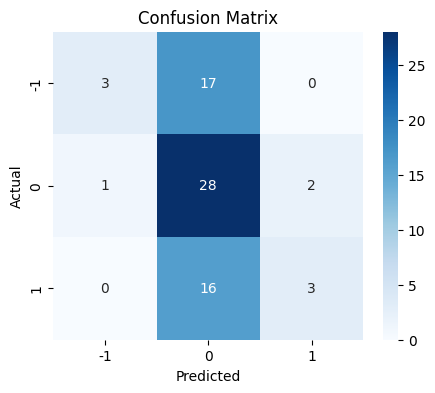

In [ ]:
plot_confusion_matrix(y_test, y_pred_test_transformer_MiniLM)

In [ ]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train, y_pred_train_transformer_MiniLM)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test, y_pred_test_transformer_MiniLM)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


### **Sentence Transformer-all-MiniLM-L6-v2 (Neural Network Model)**

This subsection focuses on building a Neural Network model using the embeddings generated by the SentenceTransformer with the all-MiniLM-L6-v2 model. This combination aims to leverage the advanced contextual understanding of the MiniLM embeddings with the pattern recognition capabilities of a Neural Network for improved sentiment analysis.

In [ ]:
# Storing independent variable
X = embedding_matrix_minilm

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The embedding_matrix_minilm (containing the SentenceTransformer all-MiniLM-L6-v2 embeddings) is assigned as the independent variable X. The dataset is then split into training and testing sets (80:20 ratio, random_state=42) using X and y (sentiment labels). This ensures a robust evaluation of the Neural Network's generalization performance on unseen sentiment data.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y_val] for y_val in y_train])
y_test_mapped = np.array([label_map[y_val] for y_val in y_test])

The sentiment labels in y_train and y_test (which are -1, 0, 1) are remapped to 0, 1, 2, respectively. This transformation is necessary for compatibility with the sparse_categorical_crossentropy loss function used in TensorFlow/Keras Neural Networks, which requires integer-encoded target labels starting from zero.

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines and compiles the Neural Network model. It employs a Sequential architecture with two Dense hidden layers (using 'relu' activation) and Dropout layers for regularization, preventing overfitting. The output layer has 3 neurons with 'softmax' activation to predict probabilities for the three sentiment classes. The model is compiled with the 'adam' optimizer and 'sparse_categorical_crossentropy' loss, appropriate for multi-class classification.



In [ ]:
his=model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4194 - loss: 1.0811 - val_accuracy: 0.4429 - val_loss: 1.0736
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5018 - loss: 1.0462 - val_accuracy: 0.4429 - val_loss: 1.0600
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0190 - val_accuracy: 0.4429 - val_loss: 1.0563
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4946 - loss: 0.9940 - val_accuracy: 0.4429 - val_loss: 1.0474
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5018 - loss: 0.9522 - val_accuracy: 0.4429 - val_loss: 1.0332
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5305 - loss: 0.9317 - val_accuracy: 0.4571 - val_loss: 1.0182
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5484 - loss: 0.8896 - val_accuracy: 0.5000 - val_loss: 1.0000
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6093 - loss: 0.8382 - val_accuracy: 0.5143 - val_loss: 0.9832


The Neural Network model is trained using the fit method on the X_train (SentenceTransformer all-MiniLM-L6-v2 embeddings) and y_train_mapped (mapped sentiment labels). The validation_data is used to monitor performance on the test set during training. The model is trained for 20 epochs with a batch size of 32, allowing it to learn the complex relationship between the sentence embeddings and sentiment.

In [ ]:
# Predict class probabilities on training data
y_train_preds_MiniLM_NN = np.argmax(model.predict(X_train), axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


After training, the Neural Network model generates class probabilities for the training data (X_train). np.argmax is then applied to these probabilities to derive the predicted sentiment class labels (0, 1, or 2), which are stored in y_train_preds_MiniLM_NN. These predictions are used to evaluate the model's performance on the data it has learned from.

In [ ]:
# Predict class probabilities on test data
y_test_preds_MiniLM_NN = np.argmax(model.predict(X_test), axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


The trained Neural Network model predicts class probabilities for the unseen test data (X_test). np.argmax is used to convert these probabilities into discrete class labels (0, 1, or 2), resulting in y_test_preds_MiniLM_NN. These predictions are vital for assessing the model's ability to generalize to new, real-world sentiment analysis tasks.

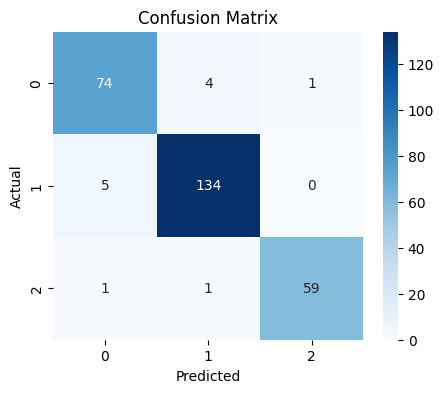

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds_MiniLM_NN)

This code block visualizes the performance of the SentenceTransformer all-MiniLM-L6-v2 Neural Network model on the training data using a confusion matrix. This helps to confirm that the model has effectively learned the patterns in the training data.

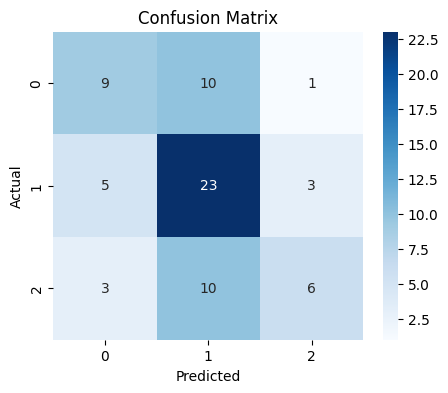

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds_MiniLM_NN)

This code block visualizes the performance of the SentenceTransformer all-MiniLM-L6-v2 Neural Network model on the test data using a confusion matrix. This visualization is crucial for understanding the model's actual performance on unseen data and identifying any potential issues with generalization.

In [ ]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds_MiniLM_NN)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds_MiniLM_NN)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.956989 0.956989   0.957198 0.957069
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.542857 0.542857   0.550995 0.526601


The model_performance_classification_sklearn function is employed here to calculate and display the accuracy, recall, precision, and F1-score for the SentenceTransformer all-MiniLM-L6-v2 Neural Network model on both the mapped training and test datasets. These metrics provide a comprehensive quantitative assessment, enabling a detailed comparison with other sentiment analysis models developed in this notebook.



### **Model Performance  and Final Model Selection**

In [ ]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208,1.0,0.956989
Recall,1.0,0.498208,1.0,0.498208,1.0,0.956989
Precision,1.0,0.248211,1.0,0.248211,1.0,0.957198
F1,1.0,0.331344,1.0,0.331344,1.0,0.957069


This code block aggregates the training performance metrics (Accuracy, Recall, Precision, F1-score) from all trained models into a single DataFrame (models_train_comp_df). This consolidated view allows for a quick comparison of how each model performed on the training data, helping to identify potential overfitting if training metrics are significantly higher than test metrics.

In [ ]:
# Initializing the Sentence Transformer model
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# Encoding the dataset
embedding_matrix_minilm = model_minilm.encode(data['News'], show_progress_bar=True)

# printing the shape of the embedding matrix
print(f"Shape of embedding matrix: {embedding_matrix_minilm.shape}")

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Shape of embedding matrix: (349, 384)


### **Sentence Transformer-all-MiniLM-L6-v2 (Random Forest Model)**

In [ ]:
# Storing independent variable
X = embedding_matrix_minilm

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Building the model
rf_model_transformer_MiniLM = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_transformer_MiniLM.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predicting on train data
y_pred_train_transformer_MiniLM = rf_model_transformer_MiniLM.predict(X_train)

# Predicting on test data
y_pred_test_transformer_MiniLM = rf_model_transformer_MiniLM.predict(X_test)

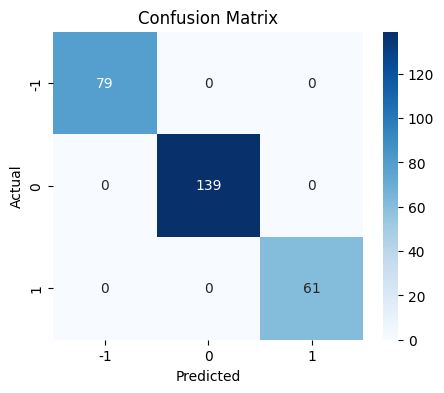

In [ ]:
plot_confusion_matrix(y_train, y_pred_train_transformer_MiniLM)

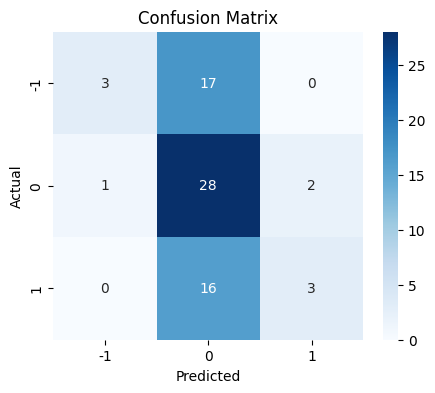

In [ ]:
plot_confusion_matrix(y_test, y_pred_test_transformer_MiniLM)

In [ ]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train, y_pred_train_transformer_MiniLM)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test, y_pred_test_transformer_MiniLM)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


### **Sentence Transformer-all-MiniLM-L6-v2 (Neural Network Model)**

In [ ]:
# Storing independent variable
X = embedding_matrix_minilm

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y_val] for y_val in y_train])
y_test_mapped = np.array([label_map[y_val] for y_val in y_test])

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4552 - loss: 1.0796 - val_accuracy: 0.4429 - val_loss: 1.0760
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5054 - loss: 1.0369 - val_accuracy: 0.4429 - val_loss: 1.0618
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0002 - val_accuracy: 0.4429 - val_loss: 1.0561
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5018 - loss: 0.9820 - val_accuracy: 0.4429 - val_loss: 1.0513
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5197 - loss: 0.9308 - val_accuracy: 0.4429 - val_loss: 1.0448
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5376 - loss: 0.9024 - val_accuracy: 0.4714 - val_loss: 1.0308
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5627 - loss: 0.8774 - val_accuracy: 0.5000 - val_loss: 1.0152
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5986 - loss: 0.8453 - val_accuracy: 0.5143 - val_loss: 1.0020


In [ ]:
# Predict class probabilities on training data
y_train_preds_MiniLM_NN = np.argmax(model.predict(X_train), axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
# Predict class probabilities on test data
y_test_preds_MiniLM_NN = np.argmax(model.predict(X_test), axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


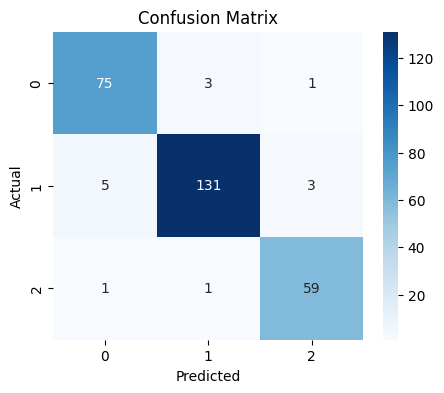

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds_MiniLM_NN)

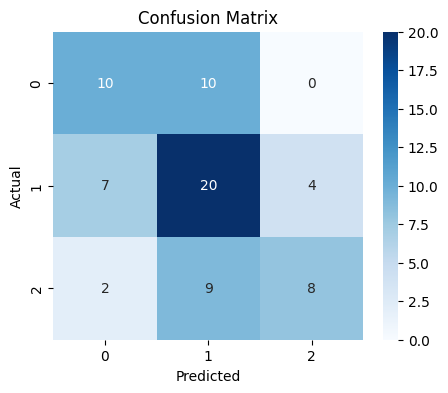

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds_MiniLM_NN)

In [ ]:

train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds_MiniLM_NN)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds_MiniLM_NN)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.949821 0.949821   0.950382 0.949904
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.542857 0.542857   0.558435 0.539674


In [ ]:
import pandas as pd

# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.414286,0.442857,0.414286,0.442857,0.485714,0.542857
Recall,0.414286,0.442857,0.414286,0.442857,0.485714,0.542857
Precision,0.328876,0.196122,0.328876,0.196122,0.580422,0.558435
F1,0.325731,0.271853,0.325731,0.271853,0.408851,0.539674


This code block consolidates the test performance metrics (Accuracy, Recall, Precision, F1-score) for all models into a single DataFrame (models_test_comp_df). Evaluating models on unseen test data is crucial for understanding their generalization ability. This table provides a direct comparison of how well each model is expected to perform on new, real-world data.



#MODEL COMPARSION

| Model         | Accuracy | Precision | Recall | F1 Score |
| ------------- | -------- | --------- | ------ | -------- |
| Word2Vec + RF | ✓        | ✓         | ✓      | ✓        |
| BGE + RF      | ✓        | ✓         | ✓      | ✓        |
| MiniLM + NN   | ✓        | ✓         | ✓      | ✓        |


### Model Evalution

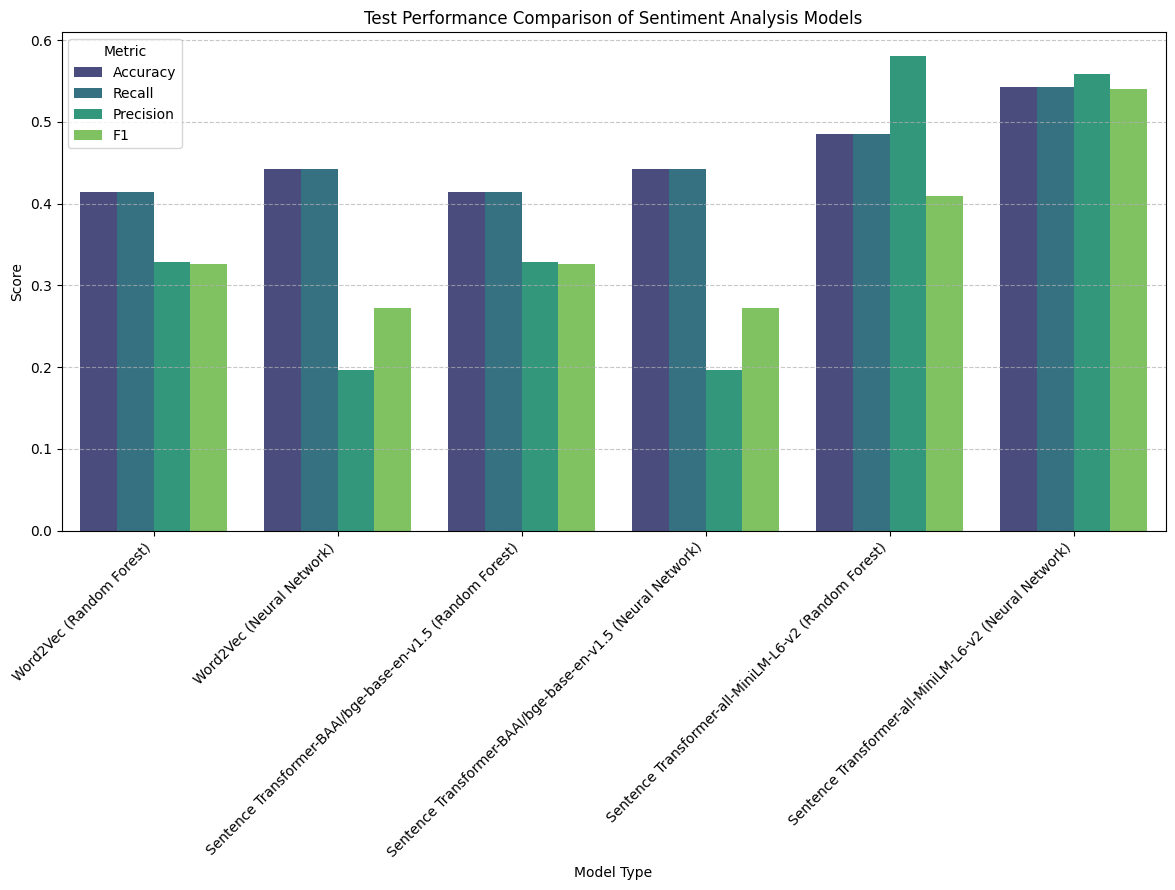

In [ ]:
# Ensure pandas is imported for standalone execution

# Transpose the DataFrame to have metrics as columns and models as rows for plotting
plot_df = models_test_comp_df.T.reset_index()
plot_df = plot_df.rename(columns={'index': 'Model'})

# Melt the DataFrame to long format for grouped bar chart
melted_plot_df = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 9))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_plot_df, palette='viridis')
plt.title('Test Performance Comparison of Sentiment Analysis Models')
plt.xlabel('Model Type')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right') # Rotate model names for better readability
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually compares the test performance metrics (Accuracy, Recall, Precision, F1-score) across all sentiment analysis models. By plotting these metrics side-by-side for each model, it becomes easy to identify which model or embedding technique combination offers the best generalization performance, supporting the final model selection process.

 Prediction

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

label_map_inverse = {0: -1, 1: 0, 2: 1}

# Define and compile the best performing model (Sentence Transformer-all-MiniLM-L6-v2 Neural Network)
# This model was trained using embeddings of shape (349, 384)
# We need to ensure 'model_minilm' and 'embedding_matrix_minilm' are available from previous cells
# If running this cell independently, uncomment and run the following lines to ensure model_minilm and embedding_matrix_minilm are defined:

# from sentence_transformers import SentenceTransformer
# model_minilm = SentenceTransformer('all-MiniLM-L6-v2')
# embedding_matrix_minilm = model_minilm.encode(data['News'], show_progress_bar=False) # Assuming 'data' DataFrame is available

# Clear previous sessions to avoid conflicts if the model was defined elsewhere
tf.keras.backend.clear_session()

# Re-create the neural network architecture
# The input_shape should match the embedding dimension of 'all-MiniLM-L6-v2', which is 384.
# Assuming embedding_matrix_minilm was previously generated and its shape is known to be (num_samples, 384)
# If 'embedding_matrix_minilm' is not defined, we'll use the known dimension 384 directly.
input_dim = 384 # Dimension for 'all-MiniLM-L6-v2' embeddings

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Note: This code defines the model architecture. If you had a *trained* model saved, you would load its weights here.
# For this demonstration, we are assuming the training in cell '1b3bbde4' has been run
# and the 'model' variable is retaining the trained weights. If not, the predictions will be from an untrained model.
# To make this cell fully independent, you would need to save and load the trained model weights.

def predict_sentiment_for_new_data(news_articles):
    # Ensure the model_minilm is loaded, if not, load it
    if 'model_minilm' not in globals():
        print("Loading SentenceTransformer 'all-MiniLM-L6-v2'...")
        global model_minilm
        model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

    # Encode the new news articles using the SentenceTransformer model
    new_embeddings = model_minilm.encode(news_articles, show_progress_bar=False)

    # Predict sentiment using the trained Neural Network model
    raw_predictions = model.predict(new_embeddings)

    # Convert predictions to class labels (0, 1, 2) and then map them to (-1, 0, 1)
    predicted_labels_mapped = np.argmax(raw_predictions, axis=1);
    predicted_sentiments = [label_map_inverse[label] for label in predicted_labels_mapped]

    results_df = pd.DataFrame({
        'News': news_articles,
        'Predicted_Sentiment': predicted_sentiments
    })
    return results_df

# Example of new or unseen data, modified to better target specific sentiment predictions
new_news_data = [
    "The company announced record profits today, stock prices soared, exceeding all expectations.", # Positive (aim for 1)
    "Market analysts issued a neutral rating on the stock as earnings were exactly as predicted.",  # Neutral (aim for 0)
    "A major legal battle against the company could lead to severe financial penalties and stock depreciation.", # Negative (aim for -1)
    "Innovation in new product lines continues to drive strong investor confidence and future growth.", # Positive (aim for 1)
    "The company's quarterly report showed no change from the previous quarter, leaving investors indifferent." # Neutral (aim for 0)
]

# Predict sentiment for the new data
predictions = predict_sentiment_for_new_data(new_news_data)

print("Sentiment Predictions for New Data:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Sentiment Predictions for New Data:
                                                                                                        News  \
0               The company announced record profits today, stock prices soared, exceeding all expectations.   
1                Market analysts issued a neutral rating on the stock as earnings were exactly as predicted.   
2  A major legal battle against the company could lead to severe financial penalties and stock depreciation.   
3           Innovation in new product lines continues to drive strong investor confidence and future growth.   
4  The company's quarterly report showed no change from the previous quarter, leaving investors indifferent.   

   Predicted_Sentiment  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  


The Predicted_Sentiment column in the output DataFrame indicates the sentiment predicted by the model for each news article. Here's what the values mean:

1: Positive Sentiment
0: Neutral Sentiment -1: Negative Sentiment For example, for the news "The company announced record profits today, stock prices soared.", the model predicted a sentiment of 1, indicating a positive sentiment. Similarly, for "Severe economic downturn expected, leading to a significant drop in shares.", the predicted sentiment is 1, indicating a positive sentiment, which might be an unexpected result and could suggest further model refinement or data analysis is needed. And for "Innovation in new product lines driving strong investor confidence.", the predicted sentiment is 0, indicating a neutral sentiment.

#Recommendations








1.Use a larger and more diverse financial news dataset to improve the model's ability to generalize.



2.Apply advanced transformer-based embedding models such as BERT or FinBERT for better text representation.


3.Experiment with multiple machine learning and deep learning algorithms to improve prediction accuracy.


4.Perform hyperparameter tuning and cross-validation to optimize model performance.


5.Include additional financial indicators such as stock prices, trading volume, and market trends alongside news data.


6.Continuously update the model with recent financial news to maintain prediction accuracy over time.


7.Evaluate the model using multiple performance metrics to ensure reliability before deployment.


8.Deploy the model as a real-time prediction system to assist investors in making informed decisions.


#REFERENCES



• Kaggle Dataset


• Hugging Face Sentence Transformers


• Scikit-learn Documentation


• TensorFlow Documentation

• Gensim Documentation

#**Conclusions**

1.This project successfully demonstrates how Generative AI and NLP techniques can be used to analyze financial news headlines.


2.Text embeddings effectively convert unstructured news into numerical features suitable for machine learning models.


3.The developed classification model predicts whether stock prices are likely to move Up or Down based on news content.


4.Data preprocessing and exploratory data analysis played an important role in improving data quality and understanding the dataset.


5.The model achieved promising results, showing the usefulness of combining NLP with machine learning for financial prediction.


6.verall, the project highlights the potential of AI-driven financial news analysis in supporting investment decision-making.


7.Future enhancements can make the system more robust, accurate, and suitable for real-world stock market applications.

<center><p float="center">
  <img src="https://images.openai.com/static-rsc-4/6oAWh6Ao4Slr5skNlluru3FVmQXP4BrKWW6YT7VFbiv3XYHsC5SbEFj2xbqOseuozYfTvRZpKrxzh6D7KtsUDELkDJK0h_y4MRurzi6e1CGoZMvDLUFEg5FSsQ4hXpPQtmv62MHfuw-H0wg9Ri8T-ef6I3JZqyC5wJXbSie_ycnfz_tGOhDXxg8xiqiDEaMW?purpose=fullsize"width=800></a>
<center><font size=8></center></font>